# Ex14c RNN stock return classification

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/sbux.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX


In [3]:
df['prevClose'] = df['close'].shift(1)


In [4]:
df.head()

,date,open,high,low,close,volume,Name,prevClose
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX,NaN
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX,28.185
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX,28.070
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX,28.130
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX,27.915


In [5]:
D = 5
T = 10
K = 1
M = 50
L = 2
bi = False
dropout = 0
lr = 0.01

### we're interested in stock return which defined by this formula $R :=\frac{V_{close}-V_{prev_close}}{V_{prev_close}}$

In [6]:
df['return'] =  (df['close']-df['prevClose'])/df['prevClose']
df['returnSign'] = df['return'] > 0


In [7]:
df.head(50)

,date,open,high,low,close,volume,Name,prevClose,return,returnSign
0,2013-02-08,27.920,28.3250,27.9200,28.1850,7146296,SBUX,NaN,NaN,False
1,2013-02-11,28.260,28.2600,27.9300,28.0700,5457354,SBUX,28.1850,-0.004080,False
2,2013-02-12,28.000,28.2750,27.9750,28.1300,8665592,SBUX,28.0700,0.002138,True
3,2013-02-13,28.230,28.2300,27.7500,27.9150,7022056,SBUX,28.1300,-0.007643,False
4,2013-02-14,27.765,27.9050,27.6750,27.7750,8899188,SBUX,27.9150,-0.005015,False
5,2013-02-15,27.805,27.8500,27.0850,27.1700,18195730,SBUX,27.7750,-0.021782,False
6,2013-02-19,27.180,27.3050,27.0100,27.2250,11760912,SBUX,27.1700,0.002024,True
7,2013-02-20,27.300,27.4200,26.5900,26.6550,12472506,SBUX,27.2250,-0.020937,False
8,2013-02-21,26.535,26.8200,26.2600,26.6750,13896450,SBUX,26.6550,0.000750,True
9,2013-02-22,26.850,27.1050,26.6400,27.0850,11487316,SBUX,26.6750,0.015370,True


In [8]:
input_data = df[['open', 'high', 'low', 'close', 'volume']].values[1:]
targets =df['returnSign'].values[1:]


In [9]:
print(input_data.shape)
print(targets.shape)

(1258, 5)
(1258,)


In [10]:
N_inp = input_data.shape[0]
Ntrain = len(input_data) * 2 // 3

In [11]:
# normalize the inputs
scaler = StandardScaler()
scaler.fit(input_data[:Ntrain + T - 1])
input_data = scaler.transform(input_data)

In [12]:
# Setup X_train and Y_train
X_train = np.zeros((Ntrain, T, D))
y_train = np.zeros((Ntrain, 1))

for t in range(Ntrain):
  X_train[t, :, :] = input_data[t:t+T]
  y_train[t] = (targets[t+T] > 0)

In [13]:
y_train[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.]])

In [14]:
# Setup X_test and Y_test
N = len(input_data) - T 
X_test = np.zeros((N - Ntrain, T, D))
y_test = np.zeros((N - Ntrain, 1))

for u in range(N - Ntrain):
  # u counts from 0...(N - Ntrain)
  # t counts from Ntrain...N
  t = u + Ntrain
  X_test[u, :, :] = input_data[t:t+T]
  y_test[u] = (targets[t+T] > 0)

In [15]:
#comment this if you want to see how lazyprogrammer made the dataset
X,y =[],[]

for t in range(input_data.shape[0]-T):
    X.append(input_data[t:t+T])
    y.append(targets[t+T] > 0)

In [19]:
y = np.array(y).reshape(-1,1)

print(y.shape)
crs = y == np.concatenate((y_train,y_test))
print(np.sum(crs))

(1248, 1)
1248


In [30]:
X_train,X_test  =  X[:Ntrain],X[Ntrain:]
y_train,y_test = y[:Ntrain],y[Ntrain:]
X_train = np.array(X_train).reshape(-1,T,D)
X_test = np.array(X_test).reshape(-1,T,D)
y_train = np.array(y_train).reshape(-1,K)
y_test = np.array(y_test).reshape(-1,K)

In [31]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [32]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(838, 10, 5)
(838, 1)
(410, 10, 5)
(410, 1)


In [33]:
X_train = torch.from_numpy(X_train.astype(np.float32)).to(device)
X_test = torch.from_numpy(X_test.astype(np.float32)).to(device)
y_train = torch.from_numpy(y_train.astype(np.float32)).to(device)
y_test = torch.from_numpy(y_test.astype(np.float32)).to(device)

In [34]:
class LSTMModel(nn.Module):
    def __init__(self, input_size,hidden_size,output_size,num_layers,bi=True,dropout=0.2):
        super().__init__()
        self.D =input_size
        self.L = num_layers
        self.M = hidden_size
        self.K = output_size

        self.biFactor = 2 if bi else 1

        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,
                           batch_first=True,
                           bidirectional=bi,dropout=dropout)
        self.fc = nn.Linear(self.M * self.biFactor, self.K)

    def forward(self,X):
        h0 = torch.zeros(self.biFactor*self.L,X.size(0),self.M).to(device)
        c0 = torch.zeros(self.biFactor*self.L,X.size(0),self.M).to(device)

        out,(hn,cn) = self.rnn(X,(h0,c0))
        out = self.fc(out[:,-1,:])
        return out


In [35]:
epochs = 300

In [36]:
lstm = LSTMModel(D,M,K,L,bi=bi,dropout=dropout)
optimizer = torch.optim.Adam(lstm.parameters(),lr=lr)
criterion = nn.BCEWithLogitsLoss()
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,max_lr=1e-3,steps_per_epoch=len(X_train), epochs=epochs)

In [37]:
lstm.to(device)

LSTMModel(
  (rnn): LSTM(5, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [38]:
# Training
def full_gd(model,
            criterion,
            optimizer,
            X_train,
            y_train,
            X_test,
            y_test,
            epochs=200):

  # Stuff to store
  train_losses = np.zeros(epochs)
  test_losses = np.zeros(epochs)

  for it in range(epochs):
    # zero the parameter gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
      
    # Backward and optimize
    loss.backward()
    optimizer.step()

    # Save losses
    train_losses[it] = loss.item()

    # Test loss
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)
    test_losses[it] = test_loss.item()
      
    if (it + 1) % 5 == 0:
      print(f'Epoch {it+1}/{epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
  
  return train_losses, test_losses

In [39]:
def single_epoch(model,optimizer: torch.optim.Optimizer,criterion: nn.Module,X,y,is_training=True):
    if is_training:
        optimizer.zero_grad()

    input = X.view(-1,T,D).to(device)
    y_hat = model(input)
    loss = criterion(y_hat,y)

    if is_training:
        loss.backward()
        optimizer.step()
        # scheduler.step(loss)
    
    return y_hat,loss.item()

    

In [40]:
train_losses, test_losses =  full_gd(lstm,
                                    criterion,
                                    optimizer,
                                    X_train,
                                    y_train,
                                    X_test,
                                    y_test,300)
# for epoch in range(epochs):
#     optimizer.zero_grad()
#     _,train_loss = single_epoch(lstm,optimizer,criterion,X_train,y_train,True)
#     _,test_loss = single_epoch(lstm,optimizer,criterion,X_test,y_test,False)
#     train_losses.append(train_loss)
#     test_losses.append(test_loss)
#     print(f'{epoch}/{epochs} train loss {train_losses[-1]} test loss {test_losses[-1]}')

Epoch 5/300, Train Loss: 0.6919, Test Loss: 0.6936
Epoch 10/300, Train Loss: 0.6905, Test Loss: 0.6921
Epoch 15/300, Train Loss: 0.6873, Test Loss: 0.6894
Epoch 20/300, Train Loss: 0.6847, Test Loss: 0.6955
Epoch 25/300, Train Loss: 0.6796, Test Loss: 0.7060
Epoch 30/300, Train Loss: 0.6744, Test Loss: 0.7162
Epoch 35/300, Train Loss: 0.6709, Test Loss: 0.7110
Epoch 40/300, Train Loss: 0.6588, Test Loss: 0.7432
Epoch 45/300, Train Loss: 0.6491, Test Loss: 0.7364
Epoch 50/300, Train Loss: 0.6326, Test Loss: 0.7565
Epoch 55/300, Train Loss: 0.6232, Test Loss: 0.7914
Epoch 60/300, Train Loss: 0.5977, Test Loss: 0.8283
Epoch 65/300, Train Loss: 0.5609, Test Loss: 0.8787
Epoch 70/300, Train Loss: 0.5384, Test Loss: 0.9422
Epoch 75/300, Train Loss: 0.5012, Test Loss: 0.9724
Epoch 80/300, Train Loss: 0.5051, Test Loss: 1.1035
Epoch 85/300, Train Loss: 0.4729, Test Loss: 1.1571
Epoch 90/300, Train Loss: 0.4420, Test Loss: 1.1394
Epoch 95/300, Train Loss: 0.4147, Test Loss: 1.2942
Epoch 100/300

In [42]:

print(f'lstm(D={D},M={M},K={K},L={L},bidirectional = {bi} dropout={dropout}) lr={lr}')

lstm(D=5,M=50,K=1,L=2,bidirectional = False dropout=0) lr=0.01


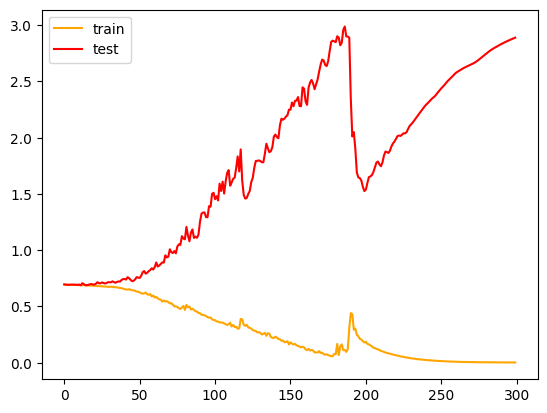

In [43]:
plt.plot(train_losses,color='orange',label='train')
plt.plot(test_losses,color='red',label='test')
plt.legend()
plt.show()

In [44]:
y_hat,_ = single_epoch(lstm,optimizer,criterion,X_test,y_test,False)
y_hat =  (y_hat > 0).detach().cpu().numpy()

In [45]:
ys = y_test.detach().cpu().numpy()

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

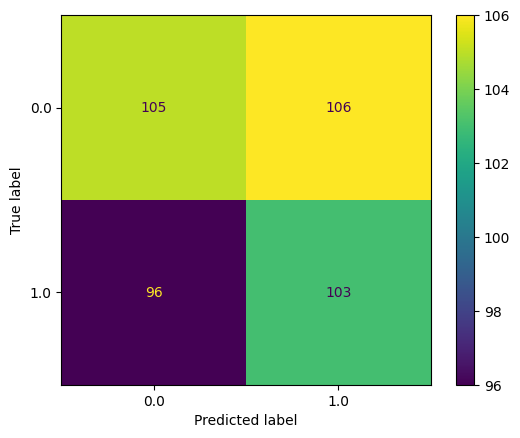

In [47]:
ConfusionMatrixDisplay.from_predictions(ys,y_hat)

In [48]:


test_acc = np.mean(y_hat == ys)

In [49]:
y_hat,_ = single_epoch(lstm,optimizer,criterion,X_train,y_train,False)
y_hat =  (y_hat > 0).detach().cpu().numpy()
train_acc = np.mean(y_hat == y_train.detach().cpu().numpy())

In [50]:
print(f'train_acc {train_acc} test_acc {test_acc}')

train_acc 1.0 test_acc 0.5073170731707317
